# Did Congestion Pricing Actually Reduce Traffic in Manhattan?

### A Difference-in-Differences Analysis of 61 Million Taxi Trips

**Shruti Pingle**

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)

## Overview

On 5 January 2025, New York City became the first city in the United States to charge drivers
a toll for entering a central business district. The Congestion Relief Zone covers Manhattan
at or below 60th Street. Vehicles entering it pay a toll, and the money goes to the MTA.

The stated goal was to reduce traffic. Whether it worked is still argued about, and the argument
usually rests on before-and-after comparisons that cannot separate the toll from everything else
that changed at the same time.

This creates a natural experiment. The toll applies inside a hard geographic boundary and not
outside it, which gives us a treatment group and a control group living through the same city,
the same weather and the same economy. That is the setup Difference-in-Differences was built for.

## Problem Statement

The core question is: **did congestion pricing reduce traffic inside the zone, and by how much?**

To answer it we need to separate the effect of the toll from the background trend in taxi
activity across the whole city. A simple before-and-after comparison cannot do that. If taxi
trips are rising everywhere, the zone can look busier after the toll even if the toll pushed
a large number of trips out of it.

### Loading the Data

The data is the NYC Taxi and Limousine Commission yellow taxi trip records, January 2024 through
June 2025. That is 65 million trips before cleaning and 61 million after.

Each trip has been labelled by where it started and where it ended:

- **treated** — the trip both starts and ends inside the Congestion Relief Zone
- **control** — neither end of the trip touches the zone

Trips that cross the boundary pay the toll but start outside it, so they belong in neither
group and are left out. The cleaning and labelling is in `python/prepare_data.py`, which
aggregates the 61 million trips down to one row per week per group.

In [2]:
df = pd.read_csv('../weekly.csv')
df['week'] = pd.to_datetime(df['week'])
df.head()

,week,group,trips,avg_speed,avg_distance,avg_duration,avg_fare
0,2024-01-01,control,75237,19.013304,7.103851,19.259086,31.546728
1,2024-01-01,treated,223796,9.551294,1.678053,10.840740,12.187777
2,2024-01-08,control,72557,16.794142,6.255857,18.991763,28.608288
3,2024-01-08,treated,266730,8.955648,1.615283,11.169707,12.163322
4,2024-01-15,control,73971,17.047986,6.160877,18.192620,28.286827


In [3]:
# the last week runs past the end of the data, so drop it
df = df[df['week'] < '2025-06-30']

# keep January to June in both years so we compare the same months
df = df[df['week'].dt.month <= 6]

# the two variables the whole analysis is built on
df['treated'] = (df['group'] == 'treated').astype(int)
df['after'] = (df['week'].dt.year == 2025).astype(int)

print(len(df), 'rows')
df.groupby(['group', 'after'])['trips'].mean().round(0)

102 rows


group    after
control  0         84047.0
         1        116265.0
treated  0        311802.0
         1        352929.0
Name: trips, dtype: float64

We keep January to June in both years. The toll started in January 2025, so if we compared
the second half of 2024 against the first half of 2025 we would be comparing summer against
winter, and seasonality would end up inside the treatment variable.

The treated group runs more than three times the size of the control group. That gap matters
later when we choose between measuring the effect in raw trips or in percentages.

## (a) The Naive Before-and-After Calculation

The obvious way to answer the question is to look at trips inside the zone before the toll and
after it. This is the calculation that gets quoted in news coverage, and it is wrong for the
same reason that counting every click on a paid advert as a new customer is wrong: it assumes
nothing else would have changed.

In [4]:
before = df[(df['treated'] == 1) & (df['after'] == 0)]['trips'].mean()
after = df[(df['treated'] == 1) & (df['after'] == 1)]['trips'].mean()

print('average weekly trips inside the zone')
print('  before the toll:', round(before))
print('  after the toll :', round(after))
print('  change         :', round(100 * (after - before) / before, 1), '%')

average weekly trips inside the zone
  before the toll: 311802
  after the toll : 352929
  change         : 13.2 %


Taken at face value this says congestion pricing **increased** traffic inside the zone by 13
percent. That is the answer you get if you ignore what was happening everywhere else.

## (b) Treatment and Control Definitions

### Unit of Observation

Each row is a **group-week** — the treated group in a given week, or the control group in a
given week. The data runs over 51 weeks across the two January to June windows.

### Treatment Group

- **Trips:** both pickup and dropoff inside the Congestion Relief Zone, Manhattan at or below 60th Street
- **Treatment:** the congestion toll
- **Timing:** from 5 January 2025

### Control Group

- **Trips:** neither pickup nor dropoff touches the zone
- **Timing:** all weeks, never tolled

The control group gives us the counterfactual: what would have happened to trips inside the
zone if the toll had never been introduced.

Zones immediately north of 60th Street are excluded from both groups. Traffic pushed out of the
zone tends to land there, which would make the control group partly treated.

### Checking the Labels Against the Toll Actually Charged

This is worth verifying rather than assuming. From 2025 the taxi records include the congestion
fee charged on each trip, so the labelling can be checked against what the city really billed.
`prepare_data.py` prints this check as it runs:

| Group | Share of 2025 trips charged the toll |
|---|---|
| treated | 99.7% |
| control | 2.6% |

An earlier version of this analysis defined treatment by pickup location alone. That same check
showed **31 percent of the control group being charged** — trips that started outside the zone
but ended inside it. A control group that is one third treated pulls any estimate towards zero,
so the definition was changed to require both ends of the trip.

The residual 2.6 percent is trips passing through the zone without starting or ending there.

## (c) First Difference Estimate

Before moving to the full model, here is the pre-post comparison written as a regression on the
treated group only.

In [5]:
first_diff = smf.ols('trips ~ after', data=df[df['treated'] == 1]).fit()
first_diff.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,3.118e+05,5263.570,59.238,0.000,3.01e+05,3.22e+05
after,4.113e+04,7517.881,5.470,0.000,2.6e+04,5.62e+04


- **`after` coefficient (+41,126):** trips inside the zone rose by about 41,000 a week after the toll
- **p-value (0.000):** the increase is statistically significant

So this model says, with confidence, that traffic went up. It is significant, it is precise,
and it is misleading.

### Why It Is Not a Good Idea to Rely on This

1. **No counterfactual.** We are only looking inside the zone. We have no idea what would have
   happened there without the toll.
2. **City-wide trends are ignored.** If taxi demand was rising across all of New York, this model
   credits that rise to the toll.
3. **It answers the wrong question.** It measures what changed, not what the toll caused.

## (d) Difference in Differences

The fix is to bring in a group that was not tolled but lived through everything else, and use it
to measure the background trend.

### Checking the Parallel Trends Assumption

DiD only works if the two groups would have moved together without the toll. They do not need to
be at the same level — the treated group is more than three times larger — they need to trend
the same way.

We test this by looking only at the period **before** the toll.

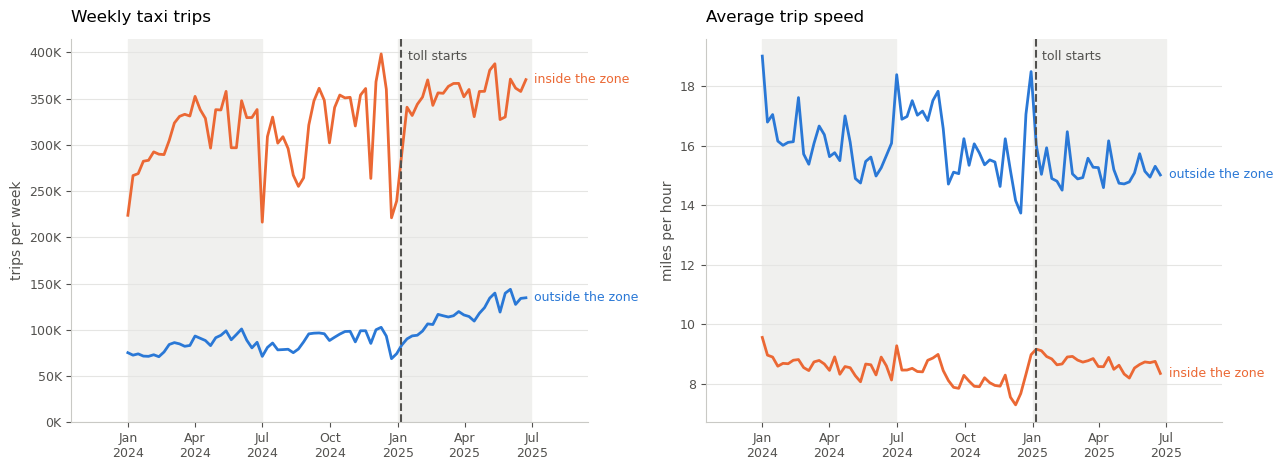

In [6]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# plot the full unfiltered series so there is no gap in the lines
full = pd.read_csv('../weekly.csv')
full['week'] = pd.to_datetime(full['week'])
full = full[full['week'] < '2025-06-30']

colours = {'treated': '#eb6834', 'control': '#2a78d6'}
labels = {'treated': 'inside the zone', 'control': 'outside the zone'}
toll_start = pd.Timestamp('2025-01-05')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, column, title, unit in [
    (axes[0], 'trips', 'Weekly taxi trips', 'trips per week'),
    (axes[1], 'avg_speed', 'Average trip speed', 'miles per hour'),
]:
    # shade the two windows the analysis compares
    for start, end in [('2024-01-01', '2024-06-30'), ('2025-01-01', '2025-06-30')]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='#f0f0ee', zorder=0)

    for name in ['treated', 'control']:
        g = full[full['group'] == name].sort_values('week')
        ax.plot(g['week'], g[column], color=colours[name], linewidth=2, label=labels[name])
        # label the line directly at its right hand end
        ax.annotate(labels[name], xy=(g['week'].iloc[-1], g[column].iloc[-1]),
                    xytext=(6, 0), textcoords='offset points',
                    color=colours[name], fontsize=9, va='center')

    ax.axvline(toll_start, color='#52514e', linestyle='--', linewidth=1.5)
    ax.annotate('toll starts', xy=(toll_start, 0.97), xycoords=('data', 'axes fraction'),
                xytext=(5, 0), textcoords='offset points',
                fontsize=9, color='#52514e', va='top')

    ax.set_title(title, fontsize=12, pad=12, loc='left')
    ax.set_ylabel(unit, fontsize=10, color='#52514e')
    ax.grid(axis='y', color='#e5e5e3', linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)
    for side in ['left', 'bottom']:
        ax.spines[side].set_color('#c9c9c5')

    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.tick_params(labelsize=9, colors='#52514e')
    ax.set_xmargin(0.14)

axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v/1000:.0f}K'))
axes[0].set_ylim(0, None)

plt.tight_layout()
plt.savefig('../images/trends.png', dpi=150, bbox_inches='tight')
plt.show()

The shaded bands are the two January to June windows the analysis compares. The unshaded stretch
in between is in the data but left out of the regressions, so that we are comparing the same
months in both years rather than summer against winter.

Reading the left chart, both lines rise across the period. That is the trap: trips inside the zone
really did go up. Reading the right chart, the two lines pull apart after the toll — the outside
line drifts down while the inside line holds flat.

In [7]:
# formal test: do the two groups trend differently before the toll?
pre = df[df['after'] == 0].copy()
pre['t'] = (pre['week'] - pre['week'].min()).dt.days / 7
pre['log_trips'] = np.log(pre['trips'])

parallel_test = smf.ols('log_trips ~ treated + t + treated:t', data=pre).fit()
parallel_test.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,11.1975,0.028,401.615,0.000,11.141,11.254
treated,1.3222,0.039,33.533,0.000,1.243,1.401
t,0.0109,0.002,5.695,0.000,0.007,0.015
treated:t,-0.0009,0.003,-0.329,0.743,-0.006,0.005


### Interpretation

The term that matters is `treated:t`, the difference in weekly trend between the two groups
before the toll. It comes out at **-0.0009 with a p-value of 0.74** — no meaningful difference
in how the two groups were moving.

The parallel trends assumption holds, so we can go ahead.

### The DiD Regression

The interaction `treated:after` is the causal estimate — the change in the treated group over and
above the change in the control group.

In [8]:
did_levels = smf.ols('trips ~ treated + after + treated:after', data=df).fit()
did_levels.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,8.405e+04,4139.336,20.304,0.000,7.58e+04,9.23e+04
treated,2.278e+05,5853.905,38.907,0.000,2.16e+05,2.39e+05
after,3.222e+04,5912.154,5.449,0.000,2.05e+04,4.4e+04
treated:after,8908.5338,8361.048,1.065,0.289,-7683.695,2.55e+04


In raw trip counts the interaction is **+8,909 with a p-value of 0.29** — not significant.

But raw counts are the wrong scale here. The treated group averages 312,000 trips a week and the
control group 84,000. A regression in levels is dominated by the larger group, and a 1 percent
move in the treated group swamps a 3 percent move in the control group.

Because the two groups are such different sizes, the effect belongs in percentages.

In [9]:
df['log_trips'] = np.log(df['trips'])

did = smf.ols('log_trips ~ treated + after + treated:after', data=df).fit()
did.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,11.3337,0.021,530.607,0.000,11.291,11.376
treated,1.3111,0.030,43.402,0.000,1.251,1.371
after,0.3202,0.031,10.495,0.000,0.260,0.381
treated:after,-0.1925,0.043,-4.463,0.000,-0.278,-0.107


In [10]:
effect = did.params['treated:after']
print('effect on trips:', round(100 * (np.exp(effect) - 1), 1), '%')
print('p-value        :', round(did.pvalues['treated:after'], 6))

effect on trips: -17.5 %
p-value        : 2.2e-05


### The Treatment Effect

**Trips inside the zone fell 17.5 percent relative to the control group (p < 0.001).**

Set against the naive estimate:

| Estimate | Result | Significant |
|---|---|---|
| Before-and-after, treated only | **+13.2%** | yes |
| Difference-in-Differences | **-17.5%** | yes |

The two do not merely differ in size — they point in opposite directions.

The reason is in the 2x2 table. Taxi trips grew everywhere over this period. The control group
grew 38 percent. The treated group grew 13 percent. Both went up, so a before-and-after
comparison sees growth and declares the toll a failure. What actually happened is that the zone
grew far less than it should have, and that shortfall is the effect of the toll.

In [11]:
table = df.pivot_table(index='group', columns='after', values='trips', aggfunc='mean').round(0)
table.columns = ['before (2024)', 'after (2025)']
table['change'] = table['after (2025)'] - table['before (2024)']
table['% change'] = (100 * table['change'] / table['before (2024)']).round(1)
table

,before (2024),after (2025),change,% change
group,,,,
control,84047.0,116265.0,32218.0,38.3
treated,311802.0,352929.0,41127.0,13.2


### Seeing the Effect

The trip counts are hard to compare directly because one group is three times the size of the
other. Rebasing both to 100 at their 2024 average puts them on the same footing, and the gap that
opens after the toll is the effect.

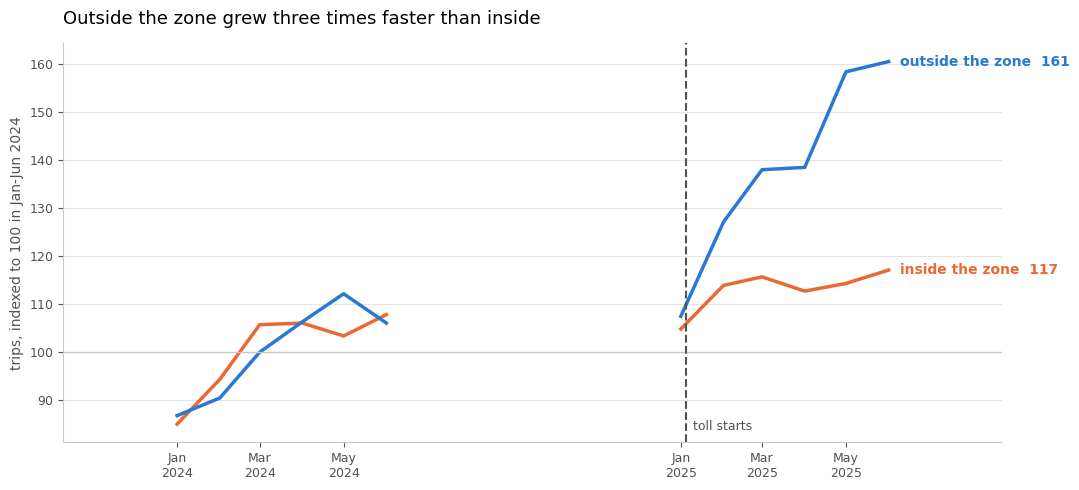

In [12]:
# rebase both groups to 100 at their January to June 2024 average
indexed = df.copy()
base = indexed[indexed['after'] == 0].groupby('group')['trips'].mean()
indexed['index'] = indexed.apply(lambda r: 100 * r['trips'] / base[r['group']], axis=1)

# average by month so the weekly noise does not hide the trend
indexed['period'] = indexed['week'].dt.to_period('M').dt.to_timestamp()
monthly = indexed.groupby(['period', 'group'])['index'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))

for name in ['treated', 'control']:
    g = monthly[monthly['group'] == name].sort_values('period')
    for year, style in [(2024, '-'), (2025, '-')]:
        part = g[g['period'].dt.year == year]
        ax.plot(part['period'], part['index'], style, color=colours[name], linewidth=2.5)
    last = g.iloc[-1]
    ax.annotate(f"{labels[name]}  {last['index']:.0f}", xy=(last['period'], last['index']),
                xytext=(8, 0), textcoords='offset points',
                color=colours[name], fontsize=10, va='center', fontweight='bold')

ax.axhline(100, color='#c9c9c5', linewidth=1)
ax.axvline(toll_start, color='#52514e', linestyle='--', linewidth=1.5)
ax.annotate('toll starts', xy=(toll_start, 0.03), xycoords=('data', 'axes fraction'),
            xytext=(5, 0), textcoords='offset points', fontsize=9, color='#52514e')

ax.set_title('Outside the zone grew three times faster than inside',
             fontsize=13, pad=14, loc='left')
ax.set_ylabel('trips, indexed to 100 in Jan-Jun 2024', fontsize=10, color='#52514e')
ax.grid(axis='y', color='#e5e5e3', linewidth=0.8)
ax.set_axisbelow(True)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax.spines[side].set_color('#c9c9c5')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(labelsize=9, colors='#52514e')
ax.set_xmargin(0.16)

plt.tight_layout()
plt.savefig('../images/indexed.png', dpi=150, bbox_inches='tight')
plt.show()

Both lines sit at 100 through the first half of 2024 and move together, which is the parallel
trends assumption in picture form. After the toll they separate. Outside the zone climbs to about
138 while inside reaches only about 113.

### The Counterfactual

The clearest way to show a Difference in Differences result is to draw what would have happened
without the treatment. If trips inside the zone had grown at the same rate as trips outside it,
the orange line would have followed the dashed path. The shaded gap is the effect of the toll.

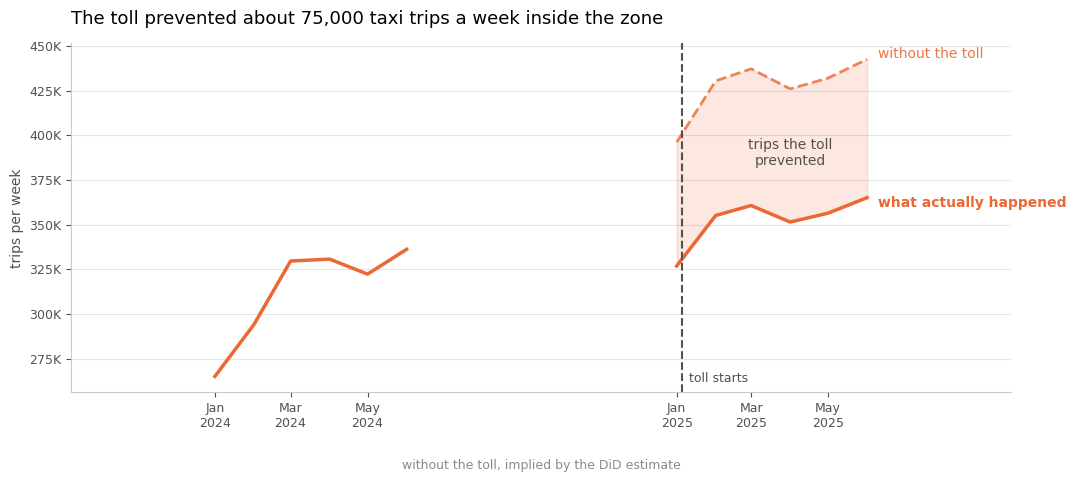

In [13]:
monthly_trips = df.copy()
monthly_trips['period'] = monthly_trips['week'].dt.to_period('M').dt.to_timestamp()
m = monthly_trips.groupby(['period', 'group'])['trips'].mean().unstack()

# the counterfactual implied by the DiD estimate: trips were held down by
# 17.5 percent, so without the toll they would have been this much higher
counterfactual = m['treated'] / np.exp(effect)

post = m.index.year == 2025
pre = m.index.year == 2024

fig, ax = plt.subplots(figsize=(11, 5))

# draw each year separately so no line is drawn across the months we left out
ax.plot(m.index[pre], m['treated'][pre], color=colours['treated'], linewidth=2.5)
ax.plot(m.index[post], m['treated'][post], color=colours['treated'], linewidth=2.5)
ax.plot(m.index[post], counterfactual[post], color=colours['treated'],
        linewidth=2, linestyle='--', alpha=0.8)
ax.fill_between(m.index[post], m['treated'][post], counterfactual[post],
                color=colours['treated'], alpha=0.15)

ax.annotate('what actually happened', xy=(m.index[-1], m['treated'].iloc[-1]),
            xytext=(8, -4), textcoords='offset points',
            color=colours['treated'], fontsize=10, va='center', fontweight='bold')
ax.annotate('without the toll', xy=(m.index[-1], counterfactual.iloc[-1]),
            xytext=(8, 4), textcoords='offset points',
            color=colours['treated'], fontsize=10, va='center', alpha=0.9)

gap_x = m.index[post][len(m.index[post]) // 2]
ax.annotate('trips the toll\nprevented', xy=(gap_x, (m['treated'][post].mean() + counterfactual[post].mean()) / 2),
            fontsize=10, color='#52514e', ha='center', va='center')
ax.annotate('without the toll, implied by the DiD estimate',
            xy=(0.5, -0.22), xycoords='axes fraction', ha='center',
            fontsize=9, color='#8a8a85')

ax.axvline(toll_start, color='#52514e', linestyle='--', linewidth=1.5)
ax.annotate('toll starts', xy=(toll_start, 0.03), xycoords=('data', 'axes fraction'),
            xytext=(5, 0), textcoords='offset points', fontsize=9, color='#52514e')

ax.set_title('The toll prevented about 75,000 taxi trips a week inside the zone',
             fontsize=13, pad=14, loc='left')
ax.set_ylabel('trips per week', fontsize=10, color='#52514e')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{v/1000:.0f}K'))
ax.grid(axis='y', color='#e5e5e3', linewidth=0.8)
ax.set_axisbelow(True)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax.spines[side].set_color('#c9c9c5')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(labelsize=9, colors='#52514e')
ax.set_xmargin(0.22)

plt.tight_layout()
plt.savefig('../images/counterfactual.png', dpi=150, bbox_inches='tight')
plt.show()

### Did Traffic Actually Move Faster?

Trip counts tell us about demand. Speed tells us about congestion, which is what the policy was
actually aiming at.

In [14]:
df['log_speed'] = np.log(df['avg_speed'])

did_speed = smf.ols('log_speed ~ treated + after + treated:after', data=df).fit()
speed_effect = did_speed.params['treated:after']

print('effect on speed:', round(100 * (np.exp(speed_effect) - 1), 1), '%')
print('p-value        :', round(did_speed.pvalues['treated:after'], 6))
print()
print(df.groupby(['group', 'after'])['avg_speed'].mean().round(2))

effect on speed: 6.5 %
p-value        : 8.7e-05

group    after
control  0        16.07
         1        15.20
treated  0         8.63
         1         8.70
Name: avg_speed, dtype: float64


**Speeds inside the zone rose 6.5 percent relative to the control group (p < 0.001).**

The raw numbers are worth reading carefully. Inside the zone, speeds went from 8.63 to 8.70 mph —
essentially flat. Outside the zone they fell from 16.07 to 15.20 mph. The rest of the city got
slower and the zone did not.

Standing still while everything around you deteriorates is an effect. It is invisible to a
before-and-after comparison, which would report a 0.8 percent speed improvement inside the zone
and call it noise.

## (e) What the Estimate Actually Means

The regression gives a percentage. Turning it into trips makes it concrete: how many taxi trips
did the toll prevent?

In [15]:
observed = df[(df['treated'] == 1) & (df['after'] == 1)]['trips'].mean()

# what the zone would have had without the toll
counterfactual = observed / np.exp(effect)
deterred = counterfactual - observed
weeks = df[(df['treated'] == 1) & (df['after'] == 1)].shape[0]

print('observed weekly trips     :', round(observed))
print('counterfactual, no toll   :', round(counterfactual))
print('trips deterred per week   :', round(deterred))
print('over', weeks, 'weeks         :', round(deterred * weeks))

observed weekly trips     : 352929
counterfactual, no toll   : 427866
trips deterred per week   : 74938
over 25 weeks         : 1873438


About **75,000 taxi trips a week** that would have run inside the zone did not, which is roughly
**1.9 million trips** over the 25 weeks measured. And this counts yellow taxis only — a fraction
of total vehicles entering the zone, so it understates the policy's total effect on traffic.

Two things follow for anyone reading the headline numbers:

1. **The naive comparison gets the sign wrong**, not just the magnitude. Reported on its own it
   supports exactly the opposite conclusion to the one the data supports.
2. **The policy worked on the measure it targeted.** Fewer trips inside the zone, and speeds
   holding steady while the rest of the city slowed down.

## Robustness Checks

A single regression is easy to get lucky with. Two things are worth testing: whether the result
survives cutting the data differently, and whether the method finds an effect where there cannot
be one.

In [16]:
def did_effect(data, outcome='log_trips'):
    m = smf.ols(outcome + ' ~ treated + after + treated:after', data=data).fit()
    c = m.params['treated:after']
    return round(100 * (np.exp(c) - 1), 1), round(m.pvalues['treated:after'], 5)

print('effect on trips under different windows')
print('  full Jan-Jun      :', did_effect(df))
print('  without Jan 2025  :', did_effect(df[~((df['week'].dt.year == 2025) & (df['week'].dt.month == 1))]))
print('  Jan-May only      :', did_effect(df[df['week'].dt.month <= 5]))
print('  Mar-Jun only      :', did_effect(df[df['week'].dt.month >= 3]))

effect on trips under different windows
  full Jan-Jun      : (-17.5, 2e-05)
  without Jan 2025  : (-20.1, 0.0)
  Jan-May only      : (-15.3, 0.00061)
  Mar-Jun only      : (-22.0, 0.0)


The estimate moves between -15 and -22 percent depending on the window, and stays significant
throughout. Dropping January 2025 — the month the toll started partway through — makes the effect
*larger*, which is what we would expect if including a partly treated month dilutes it.

In [17]:
# placebo: pretend the toll started in April 2024, a year before it really did.
# if the method is sound it should find nothing here.
placebo = df[df['after'] == 0].copy()
placebo['after'] = (placebo['week'].dt.month >= 4).astype(int)

print('placebo, fake toll in April 2024')
print('  trips:', did_effect(placebo))
print('  speed:', did_effect(placebo, 'log_speed'))

placebo, fake toll in April 2024
  trips: (-4.2, 0.34627)
  speed: (2.5, 0.27128)


The placebo finds nothing: -4.2 percent on trips with a p-value of 0.35, and 2.5 percent on speed
with a p-value of 0.27. Neither is close to significant.

This matters because it rules out the most obvious alternative explanation. If the treated and
control groups simply drifted apart for reasons unrelated to the toll, the placebo would have
picked that up too. It did not.

## Limitations

- **Yellow taxis only.** Private cars, trucks and for-hire vehicles are not in this data. Taxis
  also pay a smaller per-trip surcharge rather than the full daily toll, so their response is
  likely weaker than that of private vehicles.
- **Spillover into the control group.** If drivers shifted trips out of the zone, the control
  group grew partly *because* of the toll. That would make the 17.5 percent an overestimate.
  Zones bordering the cordon are excluded to reduce this, but it cannot be ruled out.
- **2.6 percent of control trips were charged the toll** — trips passing through the zone without
  starting or ending there.
- **January 2025 is only partly treated.** The toll started on the 5th, so the first week mixes
  both regimes.
- **Cleaning removed more rows after the toll** (5.1 percent of fares versus 2.0 percent before).
  Some of that is a change in how refunds were recorded rather than anything about traffic.
- **One year of pre-period.** A longer run-up would test parallel trends more convincingly.